In [1]:
# Library imports
import polars as pl
import os
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load position info
video_df = pl.read_csv(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\full_video_dataframe.csv")
homie_path = r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\homings\homings_obj.pkl"
with open(homie_path, "rb") as dill_file:
    homings = pickle.load(dill_file)
frame_by_cluster_matrix = np.load(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\frame_by_synthetic_cluster_matrix.npy")
video_and_spike_data = pl.read_parquet(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\synthetic_video_spike_count_df")

In [3]:
print(frame_by_cluster_matrix)
print(frame_by_cluster_matrix.shape)
print(video_df.shape)
print(video_df.columns)

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [30. 20.  0. ... 10.  0.  0.]
 [30. 20.  0. ... 10.  0.  0.]
 [10. 20.  0. ...  0.  0.  0.]]
(731210, 148)
(731210, 177)
['frames', 'hdir', 'mouse_x_position', 'mouse_y_position', 'OutofshelterIdx', 'EscapePeriod', 'shelter', 'barrier_present', 'barrier_flipped', 'hsa', 'h_bar_north_a', 'h_bar_south_a', 'h_bar_centre_a', 'head_randP_0', 'head_randP_1', 'head_randP_2', 'head_randP_3', 'head_randP_4', 'head_randP_5', 'head_randP_6', 'head_randP_7', 'head_randP_8', 'head_randP_9', 'head_randP_10', 'head_randP_11', 'head_randP_12', 'head_randP_13', 'head_randP_14', 'head_randP_15', 'head_randP_16', 'head_randP_17', 'head_randP_18', 'head_randP_19', 'head_randP_20', 'head_randP_21', 'head_randP_22', 'head_randP_23', 'head_randP_24', 'head_randP_25', 'head_randP_26', 'head_randP_27', 'head_randP_28', 'head_randP_29', 'head_randP_30', 'head_randP_31', 'head_randP_32', 'head_randP_33', 'head_rand

In [4]:
# Because of memory constraints, let's only keep the columns we need for this module
COLUMNS_TO_KEEP = [
    "frames",
    "mouse_x_position",
    "mouse_y_position",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "barrier_present",
    "barrier_flipped",
    'hsa', 
    'h_bar_north_a', 
    'h_bar_south_a',
]

# Select some columns to keep
 

In [5]:
video_df = video_df.select(COLUMNS_TO_KEEP)  # Prevents memory issues and computer crashes
# video_df = video_df.filter((video_df["barrier_present"] == True) & (video_df["barrier_flipped"] == False))
print(video_df)

shape: (731210, 11)
┌────────┬────────────┬────────────┬────────────┬─────┬────────────┬───────────┬────────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ Outofshelt ┆ ... ┆ barrier_fl ┆ hsa       ┆ h_bar_nort ┆ h_bar_sout │
│ ---    ┆ sition     ┆ sition     ┆ erIdx      ┆     ┆ ipped      ┆ ---       ┆ h_a        ┆ h_a        │
│ i64    ┆ ---        ┆ ---        ┆ ---        ┆     ┆ ---        ┆ f64       ┆ ---        ┆ ---        │
│        ┆ f64        ┆ f64        ┆ bool       ┆     ┆ bool       ┆           ┆ f64        ┆ f64        │
╞════════╪════════════╪════════════╪════════════╪═════╪════════════╪═══════════╪════════════╪════════════╡
│ 1      ┆ 282.676091 ┆ 245.210752 ┆ true       ┆ ... ┆ false      ┆ -2.340929 ┆ -2.884015  ┆ -1.619578  │
│ 2      ┆ 282.707823 ┆ 245.301877 ┆ true       ┆ ... ┆ false      ┆ -2.332812 ┆ -2.876004  ┆ -1.611392  │
│ 3      ┆ 282.735861 ┆ 245.385096 ┆ true       ┆ ... ┆ false      ┆ -2.32511  ┆ -2.868389  ┆ -1.603632  │
│ 4      ┆ 282.75

In [6]:
homings

Homings(onset_frames=array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), offset_frames=array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 2986

In [7]:
onset_frames = homings.onset_frames

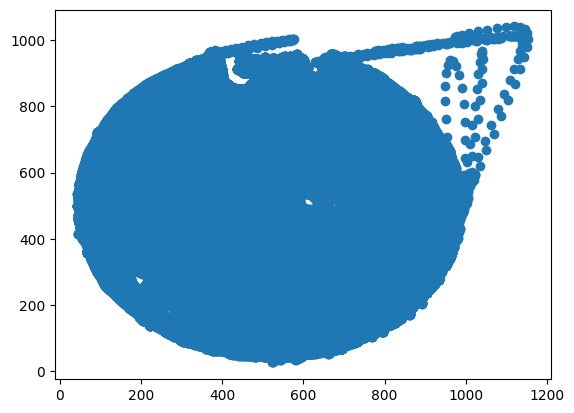

In [8]:
plt.scatter(video_df["mouse_x_position"], video_df["mouse_y_position"])

## A function to check the attributes required from the homing object exsists and to put them into a neat dictionary

In [9]:
def access_homing_attributes(homings_obj: object) -> dict:
    """Return a dictionary of verified homing attributes"""
    try:
        onset_frames = homings_obj.onset_frames
        offset_frames = homings_obj.offset_frames
    except AttributeError:
        raise AttributeError("The homings object does not have the required attributes - Something upstream is wrong with the homings object")
    assert len(onset_frames) == len(offset_frames), "The onset and offset frames are not the same length - Something is wrong with the homings object"
    return {"onset_frames": onset_frames, "offset_frames": offset_frames}

In [10]:
dic = access_homing_attributes(homings)
print(dic)
print(len(dic["onset_frames"]))

{'onset_frames': array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), 'offset_frames': array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 29862

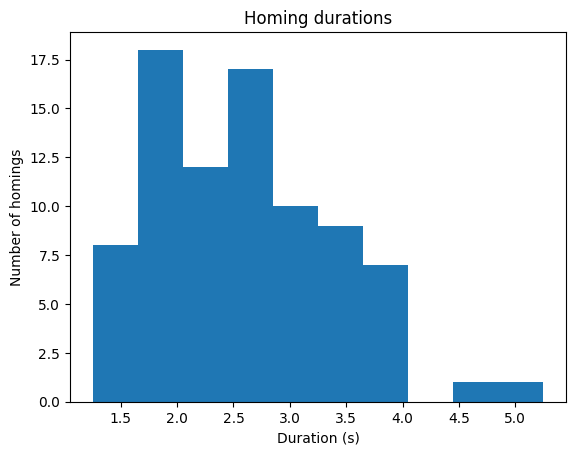

In [11]:
def plot_homing_durations(homings_dic) -> None:
    """Plot the durations of homings"""
    onset_frames = homings_dic["onset_frames"]
    offset_frames = homings_dic["offset_frames"]
    durations = (offset_frames - onset_frames) / 40 # 40 fps
    plt.hist(durations)
    plt.xlabel("Duration (s)")
    plt.ylabel("Number of homings")
    plt.title("Homing durations")
    plt.show()
plot_homing_durations(dic)

In [12]:
def check_frames_increment_by_one(arr):
    """A test to check that frames increment by 1 and as such is continuous ensuring no frames are skipped"""
    # Check each element to see if it increments by 1
    for i in range(len(arr) - 1):
        if arr[i + 1] - arr[i] != 1:
            return False
    return True

### Create some distance  bins 

[  0.          25.80645161  51.61290323  77.41935484 103.22580645
 129.03225806 154.83870968 180.64516129 206.4516129  232.25806452
 258.06451613 283.87096774 309.67741935 335.48387097 361.29032258
 387.09677419 412.90322581 438.70967742 464.51612903 490.32258065
 516.12903226 541.93548387 567.74193548 593.5483871  619.35483871
 645.16129032 670.96774194 696.77419355 722.58064516 748.38709677
 774.19354839 800.        ]


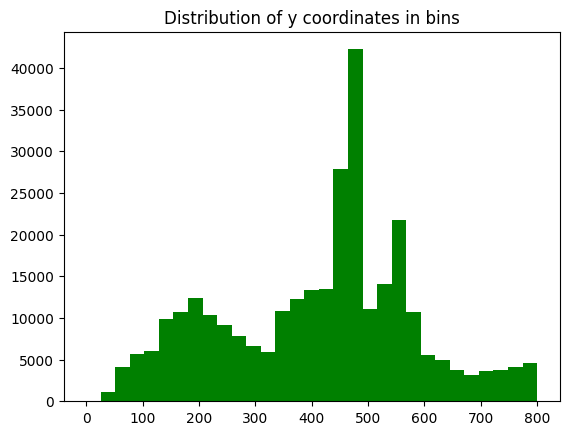

In [13]:
ycoords = video_df["mouse_y_position"]
# plt.hist(ycoords, bins=16)
# now remove y coordinats greater than 800
ycoords = ycoords.filter(ycoords < 800)
# plt.hist(ycoords, bins=16)
plt.title("Distribution of y coordinates in bins")
# 8 bins would be 10cm each, so 16 bins would be 5cm each
bins = np.linspace(0, 800, 32) # Remove near shelter as there are a lot of frames there
plt.hist(ycoords, bins=bins, color="green") # These are the defined bins
print(bins)
# NOTE there seems to be more frames around the subgoal probably due to the turn, so we should
# probably sample the frames more uniformly across bins depending on how we want to analyse the data
# TODO - Speak to jas about how she uniformly samples across bins

In [14]:
def extract_homing_info(dic, video_df):
    """Extract homing info from video_df"""
    onset_frames = dic["onset_frames"]
    offset_frames = dic["offset_frames"]
    homing_info = []
    for onset, offset in zip(onset_frames, offset_frames):
        homing = video_df[onset:offset]
        homing_bin_idx = np.digitize(homing["mouse_y_position"], bins)
        new_column = pl.Series("bin_idx", homing_bin_idx)
        homing = homing.with_column(new_column)
        # select few columns
        homing = homing.select(["frames", "mouse_x_position", "mouse_y_position", "bin_idx",  'hsa', 'h_bar_north_a', 'h_bar_south_a',])
        homing_info.append(homing)
        
    # Check the frame column of each homing information increments uniformly by 1 such that no frames are missed
    for homing in homing_info:
        assert check_frames_increment_by_one(homing["frames"].to_numpy()), "Frames are missing in the homing information"
    
    return homing_info
info = extract_homing_info(dic, video_df)
print(info[3])

shape: (82, 7)
┌────────┬─────────────────┬─────────────────┬─────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positio ┆ mouse_y_positio ┆ bin_idx ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ n               ┆ n               ┆ ---     ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---             ┆ ---             ┆ i64     ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64             ┆ f64             ┆         ┆           ┆               ┆               │
╞════════╪═════════════════╪═════════════════╪═════════╪═══════════╪═══════════════╪═══════════════╡
│ 12527  ┆ 866.017856      ┆ 227.719817      ┆ 9       ┆ 2.624716  ┆ 1.96584       ┆ 2.876886      │
│ 12528  ┆ 865.81501       ┆ 228.097034      ┆ 9       ┆ 2.567671  ┆ 1.908143      ┆ 2.821232      │
│ 12529  ┆ 865.581416      ┆ 228.560205      ┆ 9       ┆ 2.509928  ┆ 1.849622      ┆ 2.765109      │
│ 12530  ┆ 865.333292      ┆ 229.14716       ┆ 9       ┆ 2.453135  ┆ 1.79189

C:\Users\laurence\AppData\Local\Temp\ipykernel_47952\532869281.py:10: DeprecationWarning: `DataFrame.with_column` has been renamed; this redirect is temporary, please use `.with_columns` instead
  homing = homing.with_column(new_column)


shape: (109, 7)
┌────────┬─────────────────┬─────────────────┬─────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positio ┆ mouse_y_positio ┆ bin_idx ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ n               ┆ n               ┆ ---     ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---             ┆ ---             ┆ i64     ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64             ┆ f64             ┆         ┆           ┆               ┆               │
╞════════╪═════════════════╪═════════════════╪═════════╪═══════════╪═══════════════╪═══════════════╡
│ 437105 ┆ 545.473205      ┆ 97.314552       ┆ 4       ┆ -2.841595 ┆ 2.846737      ┆ -2.29099      │
│ 437106 ┆ 545.226088      ┆ 96.851737       ┆ 4       ┆ -2.817909 ┆ 2.870676      ┆ -2.267845     │
│ 437107 ┆ 544.985976      ┆ 97.119383       ┆ 4       ┆ -2.792178 ┆ 2.895581      ┆ -2.241672     │
│ 437108 ┆ 544.826798      ┆ 98.292549       ┆ 4       ┆ -2.761971 ┆ 2.9235

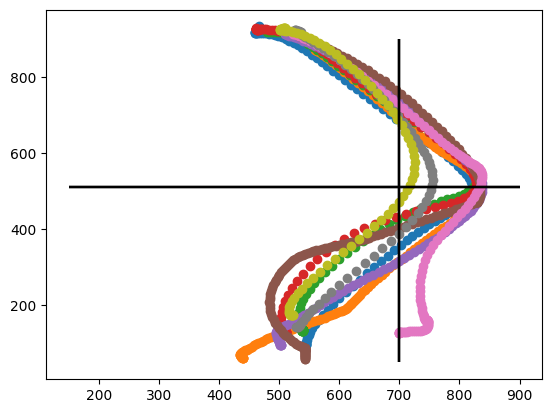

In [15]:
def select_similar_homings(info):
    """
    
    -- Similar time periods
    -- Similar mouse positions
    -- Similar targets

    Raises:
        NotImplementedError: _description_
    """
    # HARDCORE MODE - we like it rough and tough
    xcoordinate_min = 300
    xcoordinate_max = 700
    ycoordinate_min = 200
    ycoordinate_end_min = 750
    x_middle_chunk_min = 400
    x_middle_chunk_max = 600
    extracted_info = []
    for idx, homing in enumerate(info):
        
        # check if mouse x position is within the range - STARTS FARTS ONLY 
        start_x = homing["mouse_x_position"][0]
        start_y = homing["mouse_y_position"][0]
        
        # Starts in a similar space
        if start_x > xcoordinate_min and start_x < xcoordinate_max and start_y < ycoordinate_min:
            
            #Ends in a similar space
            if homing["mouse_y_position"][-1] > ycoordinate_end_min:
                
                # middle of frames is in a similar space
                middle_x = homing["mouse_x_position"][int(len(homing) / 2)]
                if middle_x < x_middle_chunk_min or middle_x > x_middle_chunk_max:
                    # plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                    # plt.hlines(y=512, xmin=150, xmax=900, color="k")
                    
                    # CHOOSE ONE SIDE
                    if middle_x > 700:
                        plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                        plt.hlines(y=512, xmin=150, xmax=900, color="k")
                        plt.vlines(x=700, ymin=50, ymax=900, color="k")
                    
                    
                        extracted_info.append(homing)
                    
    return extracted_info

extracted_info =  select_similar_homings(info)
print(extracted_info[0])
print(len(extracted_info))

### Extract the predictor


In [16]:
# If hsa is greater than h_bar_north_a, then the index will be positive
# If hsa is less than h_bar_north_a, then the index will be negative
distance_measure = lambda x, y: np.arctan2(np.sin(x - y), np.cos(x - y)) # Distance measure between two angles (vectors)

homing_data = {}
max_pred = 0
min_pred = 0
epsilon = 0.02 # For safe devision and numerical stability
for idx, homing in enumerate(extracted_info):
    # numerator = np.around((homing["hsa"].to_numpy() - homing["h_bar_north_a"].to_numpy()), decimals=2)
    numerator = np.around(distance_measure(homing["hsa"].to_numpy(), homing["h_bar_north_a"].to_numpy()), decimals=2)
    denominator = np.around((homing["hsa"].to_numpy() + homing["h_bar_north_a"].to_numpy()), decimals=2)
    # predictor = np.divide(numerator, denominator + epsilon)
    predictor = np.where(np.abs(denominator) > epsilon, numerator / (denominator + epsilon), np.nan) # Avoid small devisions all together
    # print how many nans there are per homing
    print(f"In homing {idx} there are this number of nans:", np.sum(np.isnan(predictor)))
    # check there are not more than an abitrary number of nans e.g 10
    assert np.sum(np.isnan(predictor)) < 10, "There are too many nans in the predictor, something is wrong with the data or my postdocs are not doing their job properly"
    current_min_pred = np.min(predictor)
    current_max_pred = np.max(predictor)
    if current_min_pred < min_pred:
        min_pred = current_min_pred
    if current_max_pred > max_pred:
        max_pred = current_max_pred
    new_column = pl.Series("predictor", predictor)
    homing = homing.with_columns(new_column)
    homing_data[idx] = homing
# print("Predictor index can go very high up to 141 why is this?")
# This is because if you have 0.007 for HSA and -1.13 for goal then it would equal around 162 for example
# print(homing_data[2].describe())
print(f"min pred is: {min_pred},  and max pred is {max_pred}")
pl.Config.set_tbl_rows(100)
print(homing_data[2])
print(homing_data[1])

In homing 0 there are this number of nans: 1
In homing 1 there are this number of nans: 0
In homing 2 there are this number of nans: 1
In homing 3 there are this number of nans: 1
In homing 4 there are this number of nans: 0
In homing 5 there are this number of nans: 1
In homing 6 there are this number of nans: 0
In homing 7 there are this number of nans: 0
In homing 8 there are this number of nans: 1
min pred is: -19.666666666666664,  and max pred is 8.5
shape: (101, 8)
┌────────┬────────────┬────────────┬─────────┬───────────┬──────────────┬──────────────┬───────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ bin_idx ┆ hsa       ┆ h_bar_north_ ┆ h_bar_south_ ┆ predictor │
│ ---    ┆ sition     ┆ sition     ┆ ---     ┆ ---       ┆ a            ┆ a            ┆ ---       │
│ i64    ┆ ---        ┆ ---        ┆ i64     ┆ f64       ┆ ---          ┆ ---          ┆ f64       │
│        ┆ f64        ┆ f64        ┆         ┆           ┆ f64          ┆ f64          ┆           │
╞════════╪═════════

C:\Users\laurence\AppData\Local\Temp\ipykernel_47952\3623797431.py:14: RuntimeWarning: divide by zero encountered in divide
  predictor = np.where(np.abs(denominator) > epsilon, numerator / (denominator + epsilon), np.nan) # Avoid small devisions all together


## Create a robust scaler due to outliers

In [17]:
# def robust_scale(data: np.ndarray, iqr, median):
#     """The formula of RobustScaler is (Xi-Xmedian) / Xiqr, so it is not affected by outliers. 
#     Since it uses the interquartile range, it absorbs the effects of outliers while scaling."""
    
#     # Avoid division by zero, handle case where IQR is zero
#     if iqr == 0:
#         iqr = 1
    
#     # Scale the data
#     scaled_data = (data - median) / iqr
    
#     return scaled_data

# Extract predictor across all homings and get predictor stats

The mean, median, std and IQR of the predictor are:  -0.4866235964851623 -0.3422053231939164 2.4854943668518024 0.7416108415813073


Text(0.5, 1.0, 'Distribution of predictors on log scale')

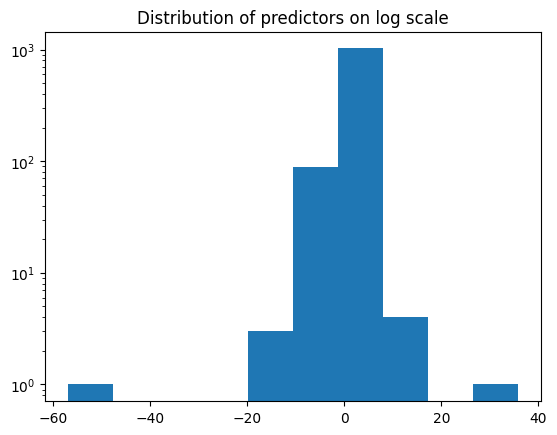

In [18]:
# Loop through the homing data and create a new array of all the predictors together
extracted_predictor = []
for idx, homing in enumerate(homing_data.values()):
    predictor = homing["predictor"]
    extracted_predictor.append(predictor.to_numpy())
flatten_extracted_predictor = np.concatenate(extracted_predictor)

# Pull at distribution statistics
median = np.nanmedian(flatten_extracted_predictor)
iqr = np.nanpercentile(flatten_extracted_predictor, 75) - np.nanpercentile(flatten_extracted_predictor, 25)
mean = np.nanmean(flatten_extracted_predictor)
std = np.nanstd(flatten_extracted_predictor)
print("The mean, median, std and IQR of the predictor are: ", mean, median, std, iqr)

# Plot the distribution of the predictors
plt.hist(flatten_extracted_predictor)
plt.yscale('log')
plt.title("Distribution of predictors on log scale")

### Because the min and max of the index is so large, let's normalise (min -462, max 3395)

shape: (6, 9)
┌────────┬────────────┬────────────┬─────────┬────┬────────────┬────────────┬─────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ bin_idx ┆ hs ┆ h_bar_nort ┆ h_bar_sout ┆ predict ┆ normalised │
│ ---    ┆ sition     ┆ sition     ┆ ---     ┆ a  ┆ h_a        ┆ h_a        ┆ or      ┆ _predictor │
│ i64    ┆ ---        ┆ ---        ┆ i64     ┆ -- ┆ ---        ┆ ---        ┆ ---     ┆ ---        │
│        ┆ f64        ┆ f64        ┆         ┆ -  ┆ f64        ┆ f64        ┆ f64     ┆ f64        │
│        ┆            ┆            ┆         ┆ f6 ┆            ┆            ┆         ┆            │
│        ┆            ┆            ┆         ┆ 4  ┆            ┆            ┆         ┆            │
╞════════╪════════════╪════════════╪═════════╪════╪════════════╪════════════╪═════════╪════════════╡
│ 437105 ┆ 545.473205 ┆ 97.314552  ┆ 4       ┆ -2 ┆ 2.846737   ┆ -2.29099   ┆ NaN     ┆ NaN        │
│        ┆            ┆            ┆         ┆ .8 ┆            ┆            ┆

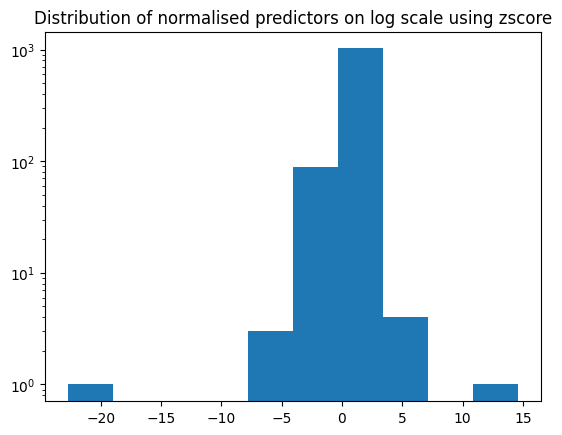

In [19]:
# Using the min and max predictor across all homings, create a new column that is a normalised version of the predictor
homing_data_normalised = {}
# extract the normalised predictor column to plot across all homings
extracted_norm_predictor = []

for idx, homing in enumerate(homing_data.values()):
    predictor = homing["predictor"]
    # normalised_predictor = robust_scale(predictor.to_numpy(), iqr, median)
    normalised_predictor = (predictor - mean) / std # zscore normalisation the predictors, mean and std are calculated from the whole dataset
    # need to fix that as data leakage, should be calculated from training data and test seperate 
    extracted_norm_predictor.append(normalised_predictor)
    new_column = pl.Series("normalised_predictor", normalised_predictor)
    homing = homing.with_columns(new_column)
    homing_data_normalised[idx] = homing
flatten_extracted_predictor = np.concatenate(extracted_predictor)
flatten_extracted_norm_predictor = np.concatenate(extracted_norm_predictor)
pl.Config.set_tbl_cols(10)
print(homing_data_normalised[0][:6]) # just show top few rows
plt.hist(flatten_extracted_norm_predictor)
plt.title("Distribution of normalised predictors on log scale using zscore")
plt.yscale('log')

### Prepare indices for design matrix

In [20]:
# get frames first
big_dic = {}
for bin_idx, bin in enumerate(bins):
    trials = {}
    for trial_idx, trial in enumerate(homing_data_normalised):
        # Filter the trial by the bin
        x = homing_data_normalised[trial]
        homing_chunk = x.filter(x["bin_idx"] == bin_idx)
        
        if len(homing_chunk) == 0:
            continue
        
        else:
            # trials[trial_idx] = homing_chunk["frames"].to_numpy()
            trials[trial_idx] = homing_chunk.select(["frames", "normalised_predictor"])
    big_dic[bin_idx] = trials
print(big_dic.keys()) # Which refers to bins
print(big_dic[20])
# print(big_dic[3][1])
# print(len(big_dic[3][2]))
    

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
{0: shape: (3, 2)
┌────────┬──────────────────────┐
│ frames ┆ normalised_predictor │
│ ---    ┆ ---                  │
│ i64    ┆ f64                  │
╞════════╪══════════════════════╡
│ 437145 ┆ -0.104316            │
│ 437146 ┆ -0.178101            │
│ 437147 ┆ -0.249656            │
└────────┴──────────────────────┘, 1: shape: (4, 2)
┌────────┬──────────────────────┐
│ frames ┆ normalised_predictor │
│ ---    ┆ ---                  │
│ i64    ┆ f64                  │
╞════════╪══════════════════════╡
│ 462715 ┆ 0.049631             │
│ 462716 ┆ 0.039707             │
│ 462717 ┆ 0.029684             │
│ 462718 ┆ 0.014536             │
└────────┴──────────────────────┘, 2: shape: (4, 2)
┌────────┬──────────────────────┐
│ frames ┆ normalised_predictor │
│ ---    ┆ ---                  │
│ i64    ┆ f64                  │
╞════════╪══════════════════════╡


# Use the big dic to index into spike cluster matrix and create design matrix

In [33]:
total_trials = len(extracted_info)
total_neurons = frame_by_cluster_matrix.shape[1]
# print("total_neurons", total_neurons)
design_matrix = np.zeros((total_trials, total_neurons))
dic_matrix = {} # A matrix containing the design matrix for each spatial bin of the homings
# big_dic.keys is distance chunks i.e seperate models for each distance chunk
# big_dic[0] is all the trials in that distance chunk
pred_dic_for_matrix = {}

# print(design_matrix[0].shape)

for homing_chunk, bin in enumerate(bins):
    trials = big_dic[homing_chunk]
    pred_vector = []
    for trial_idx in trials:
        spike_counts = np.zeros(total_neurons)
        frames = big_dic[homing_chunk][trial_idx].select("frames").to_numpy().reshape(-1)
        predictors = big_dic[homing_chunk][trial_idx].select("normalised_predictor").to_numpy().reshape(-1)
        # print("Here you can see how different the predictors are witin a bin of a trial")
        # print(predictors)
        # TODO compute some statistics on the predictors so get a sense of average in that bin
        # TODO Then attach this to a vector, and then attach this vector for that bin across all trials into a dic across all bins
        median = np.nanmedian(predictors)
        pred_vector.append(median)
        # print("meadian", median)
        for frame in frames:
            spike_counts += frame_by_cluster_matrix[frame]
        design_matrix[trial_idx] = spike_counts
    dic_matrix[homing_chunk] = design_matrix
    pred_dic_for_matrix[homing_chunk] = pred_vector
    # print(len(pred_vector))
    # print(len(design_matrix))
    # assert len(dic_matrix[homing_chunk]) == len(pred_dic_for_matrix[homing_chunk]), "The length of the design matrix and the predictor vector are not the same"

print(f"The len of the dictionary containing all of the predictor vectors is: {pred_dic_for_matrix.keys()}")
print(len(dic_matrix[10]))

for i in range(32):
    print(f"bin {i} has {pred_dic_for_matrix[i]} values")
    
# print(dic_matrix.keys())
# print(dic_matrix[0].shape)
# print(dic_matrix[0])

# NOTE
# THis could mean for example if the second trial does not go into that bin, then the neural firing will be all zeros
# either remove this, leave it in, or leave it in and regularize it so it doesn't affefct the model too muich

The len of the dictionary containing all of the predictor vectors is: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
9
bin 0 has [] values
bin 1 has [] values
bin 2 has [] values
bin 3 has [0.12949794212254706, 0.244943963030293] values
bin 4 has [1.8721789617434612, 0.08071256550491016, 0.24014930958665473, 0.29054563030172487] values
bin 5 has [0.6591789490335858, 0.09813904790482791, 0.1453920298722543, -0.8536884936351541, 0.2784135688601378] values
bin 6 has [0.13830908579505002, 0.10487111894068187, 0.24355798549027535, 0.14651212842598094, 0.09920128319422933, -1.3076748642543954, 0.2808946450793754, 0.14431851513892824] values
bin 7 has [0.11176304463156965, 0.10303543829550572, -0.451123790771108, 0.11534079901488217, 0.06287137710392436, -0.9294214610269629, 0.07594113210512245, 0.1257713526979255, 0.2450804665388345] values
bin 8 has [0.08514018018409458, 0.09182653470636665, 0.140577889063956

## Process the design matrices - Zscore across trials for individual neurons

In [22]:
from scipy import stats

zscore_design_matrix = {}
for key in dic_matrix:
    homing_chunk = dic_matrix[key]
    zscore_chunk = stats.zscore(homing_chunk, axis=0, nan_policy='raise') # Zscore the design matrix across the columns
    assert homing_chunk.shape == zscore_chunk.shape, "The zscored design matrix is not the same shape as the original design matrix"
    # Replace NaNs with 0s
    zscore_chunk = np.nan_to_num(zscore_chunk)
    assert not np.isnan(zscore_chunk).any(), "There are NaNs in the zscored design matrix"
    zscore_design_matrix[key] = zscore_chunk
    

## Now put design matrix that has been zscored into PCA

In [36]:
from sklearn import decomposition

pca_zscore_design_matrix = {}
for key in zscore_design_matrix:
    homing_chunk = zscore_design_matrix[key]
    pca = decomposition.PCA(n_components=3)
    pca_chunk = pca.fit_transform(homing_chunk)
    pca_zscore_design_matrix[key] = pca_chunk

# Fit

In [41]:
print("The length of the pca zscore design matrix is: ", len(pca_zscore_design_matrix))
for bin in pca_zscore_design_matrix:
    X = pca_zscore_design_matrix[bin]
    y = pred_dic_for_matrix[bin]
    print(X)
    print(y)
    assert X.shape[0] == len(y), "The number of rows in the design matrix and the predictor vector are not the same"

The length of the pca zscore design matrix is:  32
[[-6.13367447 -2.77980613 -0.92811838]
 [ 9.24191982 -5.00329378 -3.12861718]
 [-4.38913849 -6.78382056  4.5457338 ]
 [-3.55424769 -0.49458696  1.64298919]
 [-0.26694973  4.69257101 -2.23647858]
 [ 5.95132248  3.8301049   8.57935737]
 [-0.27418792  2.00014108 -2.49602289]
 [ 2.11720698 -2.31152845 -4.03857924]
 [-2.69225098  6.8502189  -1.94026409]]
[]


AssertionError: The number of rows in the design matrix and the predictor vector are not the same